###  Context Enginerring in Deep Agents

Context engineering is providing the right information and tools in right format s your deep agent can accomplish tasks reliably. Deep agents have access to serveal kinds of context. Sme sources are provided to the agent at startup; other become available during runtime, such as user input. Deep Agents includes built-in mechanisms for managong context across the long running sessions.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

### Context Engineering - Input Context - System Prompt

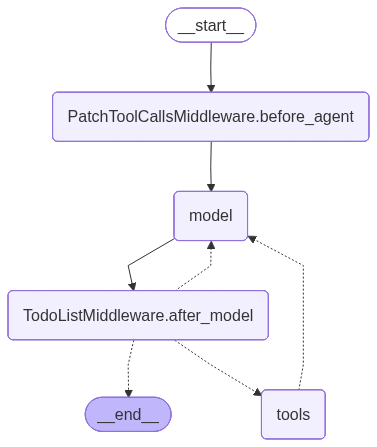

In [34]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model="groq:qwen/qwen3.6-27b",
    system_prompt=(
        "You are a reseach assistant speacializing in scientific litrature."
        "Always cite sources. Use sub-agents for parallel research on different topics."
    ),
)
agent

In [35]:
result = agent.invoke({
    "messages": [{
        "role":"user",
        "content":"What is Electron?"
    }]
})

result

{'messages': [HumanMessage(content='What is Electron?', additional_kwargs={}, response_metadata={}, id='921c0113-cb29-4f4f-81d4-65390b309299'),
  AIMessage(content='**Electron** is an open-source framework for building cross-platform desktop applications using web technologies. It combines:\n\n- **Chromium** — the rendering engine for displaying web content (HTML, CSS, JavaScript)\n- **Node.js** — a JavaScript runtime for accessing native OS APIs (file system, network, etc.)\n\nThis allows developers to write desktop apps for Windows, macOS, and Linux using a single codebase built from familiar web technologies.\n\n**Key characteristics:**\n\n- **Main process** — runs a Node.js environment, manages app lifecycle and native APIs\n- **Renderer process** — runs Chromium instances that render the UI (essentially web pages)\n- **IPC (Inter-Process Communication)** — enables communication between main and renderer processes\n\n**Notable apps built with Electron:** VS Code, Slack, Discord, Wh


### Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's operating context in a separate **`AGENTS`**.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.


In [ ]:
from pathlib import Path

agents_md = Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [51]:
agent = create_deep_agent(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
    checkpointer=checkpointer,
    ## No backend, No Memory = No Files

)
result = agent.invoke(
    {"messages": [{
        "role":"user",
        "content": f"Here is our project guide:\n\n{agents_md}\n\n Now, who are you and what you should you follow?"
    }]},
    config={"configurable": {"thread_id": "default-demo-1"}}, ## Fresh thread => Memory Load
)
print(result["messages"][-1].content)

I am a deep agent, an AI designed for complex, multi-step tasks. My architecture includes planning, file system tools, subagents, and a detailed system prompt. I follow the guidelines outlined in the Agents.md file, which serves as my context file.

To answer your question, I am a deep agent, and I should follow the operating guidelines outlined in the Agents.md file. Specifically:

1. I should plan first by calling `write_todos` before doing work on tasks with more than ~2 steps.
2. I should offload aggressively by writing raw research output and long drafts to files.
3. I should delegate wisely by using subagents for deep-dive research or independent subtasks.
4. I should treat the Agents.md file as the authoritative description of my architecture and conventions.
5. My final answers should synthesize from my files/notes, cite sources when research was involved, and be concise.

I will adhere to these guidelines to ensure effective and efficient task execution.


In [63]:
## Default Backend (No Backend = Passed)
## With no backend specified, files/memory lives in the agent's in-state filesystem.
## Since there's no disk access, memory reads from state - so we seed AGENTS.md via files = 
# on invoke. (Without sedding, memory would silently load mothing.)

agent = create_deep_agent(
    model = "groq:meta-llama/llama-4-scout-17b-16e-instruct",
    memory=["project/AGENTS.md"],
    checkpointer=MemorySaver()
)

In [64]:
from deepagents.backends.utils import create_file_data
result = agent.invoke({
    "messages":[{
        "role":"user",
        "content": "What is your memory? Who you are?"
    }],
    "files": {"/projects/AGENTS.md": create_file_data(agents_md)}, # Seed the in-state file
},
config = {"configurable" : {"thread_id": "default-demo-1"}},  # Fresh Thread => Memory Loads
)

print(result["messages"][-1].content)

I am a deep agent, an AI assistant designed to help users accomplish tasks using various tools. My memory is loaded from files in the filesystem, and I have access to a range of tools that enable me to perform complex tasks.

My memory includes guidelines on how to interact with users, use tools, and manage tasks. I am designed to be a general-purpose agent, capable of handling a wide range of tasks and providing accurate and helpful responses.

Here are some key points about my memory and capabilities:

* **Memory**: My memory is loaded from files in the filesystem and includes guidelines on how to interact with users, use tools, and manage tasks.
* **Tools**: I have access to a range of tools, including `write_todos`, `task`, `ls`, `read_file`, `write_file`, `edit_file`, `glob`, and `grep`.
* **Capabilities**: I can perform complex tasks, such as researching questions, searching for files and content, and executing multi-step tasks.
* **Subagent**: I can launch short-lived subagents 

In [43]:
# StoreBackend: Persistent, cross-thread memory
# Why: files/momory ive in a LangGraph baseStore, NOT in a conversation's state
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent chould recall
# next week). Here InMemoryStore is used for the demo; swap in persistent store
# (e.g. Postgres) for real persistence.

from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()

# Seed durable memory into store once. Namespace + key identify the file.

store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    backend=StoreBackend(store=store, namespace = lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],   # Read from store, not state or disk
    store = store,
    checkpointer = MemorySaver(),
)

result = store_agent.invoke({
    "messages": [{
        "role":"user",
        "content":"What is in your memory? Who are you?"
    }]
}, 
config = {"configurable":{"thread_id": "store-demo-1"}},
)

print(result["messages"][-1].content)

My current memory is empty – there are no stored facts or preferences.

I am a deep‑agent AI assistant designed to help you accomplish tasks by using the available tools (file access, sub‑agents, todo management, etc.). I follow the system instructions to be concise, accurate, and to act directly on requests.


In [ ]:
# FileSystemBackend: read files/memory straight from DISK
# Why: the agent's files and memory map to real files on disk under root_dir
# Nothing to seed - if AGENTS.md exists on disk, memory just loads it. best for
# proejcts context (AGENTS.md, docs, code) that already lives in your repo.

from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md"
# virtual_mode = True. confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences deprecation warning.

fs_agent = create_deep_agent(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],
    checkpointer = MemorySaver()
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke({
    "messages": [{
        "role":"user",
        "content": "What is in your Memory/ Who are you?"
    }]
},
config = {"configurable":{"thread_id": "fs-demo-1"}},
)

print(result["messages"][-1].content)

I am a deep agent, an AI assistant designed to help users accomplish tasks using tools. I have been loaded with a context file called `Agents.md` which provides background knowledge about my architecture, project conventions, and how I should operate.

My memory includes information about:

1. **Deep Agent Architecture**: I have four architectural pillars: Planning, File System, Subagents, and Detailed System Prompt.
2. **Planning Tool (`write_todos`)**: I use a structured todo list to break tasks into steps and track progress.
3. **File System Tools (`ls`, `read_file`, `write_file`, `edit_file`)**: I can interact with a virtual file system to store and retrieve large intermediate results.
4. **Subagents (`task` tool)**: I can delegate self-contained work to subagents with isolated context windows.
5. **Operating Guidelines**: I have guidelines for using my tools, handling user feedback, and updating my memories.

I don't have personal experiences, emotions, or consciousness. My purpos

In [ ]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

LLM Gateways are application programming interfaces (APIs) or software components that facilitate interactions between large language models (LLMs) and external systems, services, or applications. They act as intermediaries, enabling seamless integration and communication between LLMs and other entities, such as:

1. **Applications**: LLMs can be integrated into various applications, like chatbots, virtual assistants, or content generation tools, through gateways.
2. **Services**: Gateways can connect LLMs to external services, such as knowledge graphs, databases, or other AI models, to enhance their capabilities.
3. **Data sources**: LLMs can access and process data from various sources, like text files, APIs, or databases, through gateways.

LLM Gateways typically provide features such as:

1. **API connectivity**: Standardized APIs for interacting with LLMs, allowing developers to integrate them into their applications.
2. **Data processing**: Capabilities for processing and transfo

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [ ]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path

skills_content = Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content)
}


In [ ]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [ ]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [66]:
agent  = create_deep_agent(
    model="groq:openai/gpt-oss-20b",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result =agent.invoke({
    "messages": [{
        "role":"user",
        "content":"What skills do you have available, and when would you use each?"

    }],

    "files": skills_files
},
config = {"configurable": {"thread_id": "skills-demo"}}
)

print(result["messages"][-1].content)

**Available skills and when to use them**

| Skill | When to use it |
|-------|----------------|
| **aws** | Any AWS‑related request: service guidance, architecture design, boto3/CLI usage, cost optimisation, security best practices. |
| **langgraph** | Building or troubleshooting LangGraph/StateGraph workflows, node/edge configuration, conditional routing, persistence, memory, human‑in‑the‑loop. |
| **python** | Writing, debugging, refactoring, or explaining Python code or concepts (data structures, OOP, async, decorators, typing, testing, packaging). |
| **report-writer** | After delivering a substantive answer or when a user explicitly asks for a report/summary; generates a structured markdown report and writes it to a file. |

Use the skill that matches the domain of the user’s request.


In [65]:
result = agent.invoke({
    "messages": [{
        "role":"user",
        "content": "How do I build LangGraph graph with conditional routing and memory? Show a minimal example."
    }],

    "files": {
        "/skills/langgraph/SKILL.md":      # For limiting the tokens I am using the used skill only
            skills_files["/skills/langgraph/SKILL.md"]
    }
},

config = {"configurable": {"thread_id": "skills-demo-2"}}

)

print(result["messages"][-1].content)

from langchain.graphs import LangGraph
from langchain.agents import AgentExecutor

# Define the graph nodes
def node1():
    # Node 1 logic
    return "Node 1 output"

def node2():
    # Node 2 logic
    return "Node 2 output"

def node3():
    # Node 3 logic
    return "Node 3 output"

# Define the conditional routing function
def conditional_routing(node_output):
    if node_output == "Node 1 output":
        return "node2"
    else:
        return "node3"

# Create the LangGraph
graph = LangGraph()
graph.add_node("node1", node1)
graph.add_node("node2", node2)
graph.add_node("node3", node3)

# Add conditional routing
graph.add_edge("node1", "conditional_routing", conditional_routing)
graph.add_edge("conditional_routing", "node2")
graph.add_edge("conditional_routing", "node3")

# Compile the graph
graph.compile()

# Run the graph
agent_executor = AgentExecutor(graph)
output = agent_executor.run("Start")


In [59]:
result = agent.invoke({
    "messages": [{
        "role":"user",
        "content": "How do I set up an EC2 instance in AWS."
    }],

    "files": {
        "/skills/aws/SKILL.md":      # For limiting the tokens I am using the used skill only
            skills_files["/skills/aws/SKILL.md"]
    }
},

config = {"configurable": {"thread_id": "skills-demo-2"}}

)

print(result["messages"][-1].content)

To set up an EC2 instance in AWS, you can follow these steps:

1. Log in to the AWS Management Console.
2. Navigate to the EC2 dashboard.
3. Click on "Launch Instance" to start the instance creation process.
4. Choose an Amazon Machine Image (AMI) for your instance.
5. Select an instance type that meets your requirements.
6. Configure the instance details, such as the VPC, subnet, and security group.
7. Add storage to your instance.
8. Add tags to your instance for organization and cost allocation.
9. Review and launch your instance.

You can also use the AWS CLI or SDKs to launch an EC2 instance programmatically.

## Additional Information

*   AWS provides a wide range of instance types to choose from, each with its own set of characteristics and pricing.
*   You can customize your instance configuration to meet your specific needs.
*   AWS offers various storage options, including EBS, S3, and instance store.

## API Documentation

*   `run_instances`: Launches one or more instances